<a href="https://colab.research.google.com/github/sascha-pst/McCombs-DSBA/blob/main/Full_Code_Notebook_EasyVisa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EasyVisa: Predicting Visa Certification with Ensemble Models

> A classification project on 25,480 US work-visa applications. I explore which applicant and employer traits go with certification, compare eight models on original, oversampled and undersampled training data, tune four ensemble models, and turn the final model into a profile of which applications to fast-track and which to review closely.

## Executive Summary

| # | Finding | Evidence | So what |
|---|---|---|---|
| 1 | **Education is the biggest single factor** | Certification rises from **34%** for high school to **62%** (Bachelor's), **79%** (Master's) and **87%** (Doctorate) | Education level should anchor any applicant profile |
| 2 | **Job experience matters** | **75%** certified with experience vs **56%** without | Experience is the second clear signal |
| 3 | **Hourly-wage jobs are a red flag; wage level is not** | Hourly jobs are certified **35%** of the time vs **70%** for yearly-wage jobs. Within yearly wages, the rate is flat (**69–72%**) across wage quartiles | Review hourly-wage applications closely; don't treat a higher wage as a positive sign |
| 4 | **The factors stack** | Master's or Doctorate + experience + yearly wage: **91%** certified (6,529 cases). High school without experience: **32%** | Simple, explainable rules already separate strong and weak applications |
| 5 | **The model is a triage tool, not a decision-maker** | Final model (Gradient Boosting) scores **0.82 F1** on unseen data. Its top-scored quarter is certified **90%** of the time, the bottom quarter **35%**. It catches 91% of certifications but only 38% of denials | Use it to fast-track likely approvals, and keep human review for everything else |

Details, charts and recommendations follow below.

## Business Context

US employers can hire foreign workers when they show there aren't enough qualified US workers available at the prevailing wage. The Office of Foreign Labor Certification (OFLC) reviews these applications, and the volume keeps growing: in FY2016 it processed 775,979 applications covering 1.7 million positions, up 9% on the year before.

OFLC has asked EasyVisa to build a model that:

* **speeds up review** by flagging applications that are likely to be certified, and
* **describes the applicant profile** that tends to be certified or denied, based on the factors that drive the decision.

### Data Dictionary

| Column | Description |
|---|---|
| `case_id` | Application ID |
| `continent` | Employee's continent of origin |
| `education_of_employee` | High School, Bachelor's, Master's or Doctorate |
| `has_job_experience` | Does the employee have job experience? (Y/N) |
| `requires_job_training` | Does the employee need job training? (Y/N) |
| `no_of_employees` | Number of employees at the sponsoring company |
| `yr_of_estab` | Year the company was founded |
| `region_of_employment` | US region where the employee will work |
| `prevailing_wage` | Average wage for similar jobs in that area, so foreign workers aren't underpaid |
| `unit_of_wage` | Unit of the prevailing wage: Hour, Week, Month or Year |
| `full_time_position` | Is the position full-time? (Y/N) |
| `case_status` | **Target:** Certified or Denied |

## 1. Setup and Data Loading

In [1]:
# Pinned versions for reproducibility (Colab)
!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.2.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [32 lines of output]
      Traceback (most recent call last):
        File "/usr/lib/python3/dist-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 353, in <module>
          main()
          ~~~~^^
        File "/usr/lib/python3/dist-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 335, in main
          json_out['return_val'] = hook(**hook_input['kwargs'])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "/usr/lib/python3/dist-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 112, in get_requires_for_build_wheel
          backend = _build_backend()
        File "/usr/lib/python3/dist-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 77, in _build_backend
          obj = import_module(mod_path)
        File "/usr/lib/python3.13/importlib/__init__

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier)
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Consistent styling for every chart in the report
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
BASE = "#9BB0C8"      # neutral bars
ACCENT = "#1F4E79"    # highlighted bars / key series
SEED = 1              # one random seed everywhere, so results are reproducible
pd.set_option("display.max_columns", None)

In [3]:
# Load the data ONCE; every later cell works from this dataframe.
# In Colab, upload EasyVisa.csv to the session first (or change the path).
raw = pd.read_csv("EasyVisa.csv")
df = raw.copy()
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


## 2. Data Overview and Cleaning

In [4]:
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
print(f"Duplicate rows: {df.duplicated().sum()}   Missing values: {df.isnull().sum().sum()}")
df.dtypes

Rows: 25,480   Columns: 12
Duplicate rows: 0   Missing values: 0


case_id                      str
continent                    str
education_of_employee        str
has_job_experience           str
requires_job_training        str
no_of_employees            int64
yr_of_estab                int64
region_of_employment         str
prevailing_wage          float64
unit_of_wage                 str
full_time_position           str
case_status                  str
dtype: object

In [5]:
df.describe().round(2)

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.00,25480.00,25480.00
mean,5667.04,1979.41,74455.81
std,22877.93,42.37,52815.94
min,-26.00,1800.00,2.14
25%,1022.00,1976.00,34015.48
50%,2109.00,1997.00,70308.21
75%,3504.00,2005.00,107735.51
max,602069.00,2016.00,319210.27


In [6]:
df.describe(include="object")

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,region_of_employment,unit_of_wage,full_time_position,case_status
count,25480,25480,25480,25480,25480,25480,25480,25480,25480
unique,25480,6,4,2,2,5,4,2,2
top,EZYV01,Asia,Bachelor's,Y,N,Northeast,Year,Y,Certified
freq,1,16861,10234,14802,22525,7195,22962,22773,17018


In [7]:
# Two things in the summary above need a closer look
neg_employees = (df["no_of_employees"] < 0).sum()
print(f"Companies with a negative employee count: {neg_employees}")
print("\nPrevailing wage by unit:")
df.groupby("unit_of_wage")["prevailing_wage"].agg(["count", "min", "median", "max"]).round(2)

Companies with a negative employee count: 33

Prevailing wage by unit:


,count,min,median,max
unit_of_wage,,,,
Hour,2157,2.14,372.65,999.92
Month,89,1599.28,81826.01,264362.95
Week,272,2183.23,85075.82,280175.95
Year,22962,100.00,76174.50,319210.27


**Sanity checks.** The file has no missing values and no duplicates. Two columns need attention:

* 33 companies report a **negative number of employees**. The magnitudes look like normal company sizes, so I read these as sign typos and take the absolute value.
* `prevailing_wage` mixes **hourly, weekly, monthly and yearly** figures, which is why the minimum is about \$2. Raw wages can only be compared within the same unit, so the wage analysis below does that.

`case_id` is just a label, so I drop it. I also add a 0/1 `certified` column to make rates easy to calculate.

In [8]:
df["no_of_employees"] = df["no_of_employees"].abs()
df = df.drop(columns="case_id")
df["certified"] = (df["case_status"] == "Certified").astype(int)

## 3. What Goes With Certification?

Every chart in this section shows the **certification rate** for each group, so groups of different sizes can be compared directly. The dashed line marks the overall rate, and dark bars are groups above it.

In [9]:
overall_rate = df["certified"].mean()

def cert_rates(col, order=None):
    """Certification rate and number of cases for each value of `col`."""
    rates = df.groupby(col)["certified"].agg(rate="mean", cases="size")
    return rates.reindex(order) if order else rates.sort_values("rate", ascending=False)

def plot_rates(rates, title):
    """Horizontal bar chart of certification rates, with the overall rate as a reference line."""
    fig, ax = plt.subplots(figsize=(8.5, 0.55 * len(rates) + 1.3))
    ax.barh(rates.index.astype(str), rates["rate"],
            color=[ACCENT if r >= overall_rate else BASE for r in rates["rate"]])
    ax.invert_yaxis()
    ax.axvline(overall_rate, color="firebrick", linestyle="--", linewidth=1)
    for y, (r, n) in enumerate(zip(rates["rate"], rates["cases"])):
        ax.text(r + 0.01, y, f"{r:.0%}  (n={n:,})", va="center", fontsize=9)
    ax.set_xlim(0, 1.18)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(title)
    ax.set_xlabel(f"Certification rate   |   dashed line = overall rate ({overall_rate:.0%})")
    ax.set_ylabel("")
    plt.tight_layout(); plt.show()

### 3.1 How are case outcomes split?

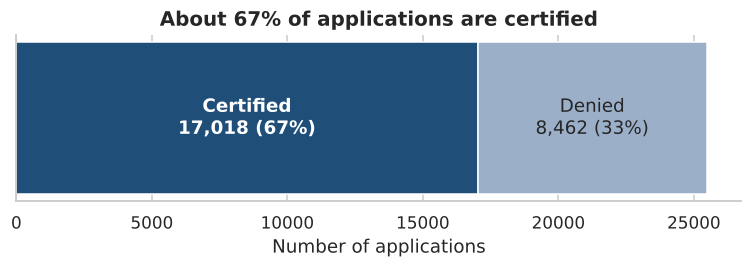

In [10]:
status = df["case_status"].value_counts()

fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(["Cases"], [status["Certified"]], color=ACCENT)
ax.barh(["Cases"], [status["Denied"]], left=[status["Certified"]], color=BASE)
ax.text(status["Certified"] / 2, 0, f"Certified\n{status['Certified']:,} ({overall_rate:.0%})",
        ha="center", va="center", color="white", fontweight="bold")
ax.text(status["Certified"] + status["Denied"] / 2, 0, f"Denied\n{status['Denied']:,} ({1 - overall_rate:.0%})",
        ha="center", va="center")
ax.set_title(f"About {overall_rate:.0%} of applications are certified")
ax.set_xlabel("Number of applications"); ax.set_yticks([])
plt.tight_layout(); plt.show()

Two out of three applications are certified. The classes are imbalanced but not extremely so. One consequence for modeling: a "model" that certifies everyone would already be right 67% of the time, so accuracy alone would flatter weak models.

### 3.2 Education

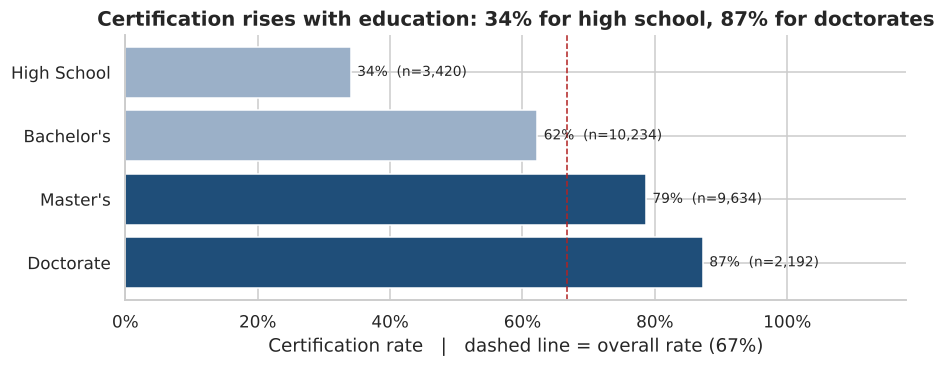

In [11]:
edu = cert_rates("education_of_employee", order=["High School", "Bachelor's", "Master's", "Doctorate"])
plot_rates(edu, f"Certification rises with education: {edu['rate'].iloc[0]:.0%} for high school, "
                f"{edu['rate'].iloc[-1]:.0%} for doctorates")

### 3.3 Job experience and training

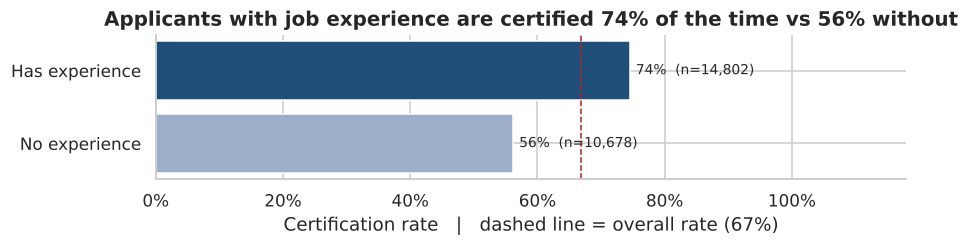

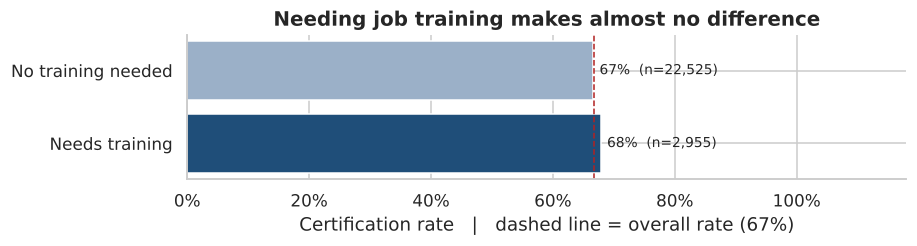

In [12]:
exp = cert_rates("has_job_experience", order=["Y", "N"]).rename(index={"Y": "Has experience", "N": "No experience"})
plot_rates(exp, f"Applicants with job experience are certified {exp['rate'].iloc[0]:.0%} of the time "
                f"vs {exp['rate'].iloc[1]:.0%} without")

train = cert_rates("requires_job_training", order=["N", "Y"]).rename(index={"N": "No training needed", "Y": "Needs training"})
plot_rates(train, "Needing job training makes almost no difference")

### 3.4 Wages

Because wages come in different units, I look at two things: certification by **wage unit**, and certification by **wage level** among yearly-wage applications only (the large majority).

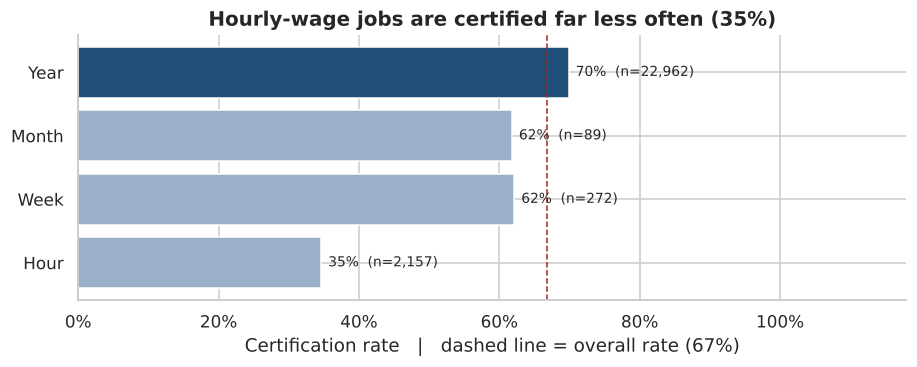

In [13]:
unit = cert_rates("unit_of_wage", order=["Year", "Month", "Week", "Hour"])
plot_rates(unit, f"Hourly-wage jobs are certified far less often ({unit.loc['Hour', 'rate']:.0%})")

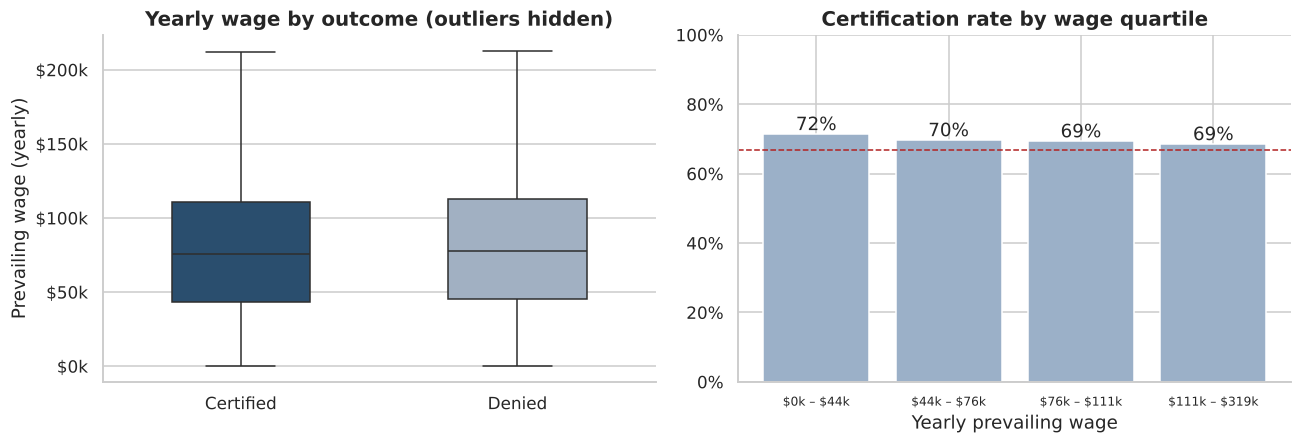

,count,mean,std,min,25%,50%,75%,max
case_status,,,,,,,,
Certified,16047.0,80746.0,50482.0,100.0,42989.0,75428.0,110654.0,318446.0
Denied,6915.0,82346.0,48684.0,153.0,45450.0,77697.0,112564.0,319210.0


In [14]:
yearly = df[df["unit_of_wage"] == "Year"].copy()
yearly["wage_band"] = pd.qcut(yearly["prevailing_wage"], 4)
band_rates = yearly.groupby("wage_band")["certified"].agg(rate="mean", cases="size")
band_rates.index = [f"\\${b.left / 1000:,.0f}k – \\${b.right / 1000:,.0f}k" for b in band_rates.index]  # \$ = literal $ in matplotlib

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.boxplot(data=yearly, x="case_status", y="prevailing_wage", order=["Certified", "Denied"],
            hue="case_status", palette={"Certified": ACCENT, "Denied": BASE}, legend=False,
            width=0.5, showfliers=False, ax=axes[0])
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v / 1000:,.0f}k"))
axes[0].set_title("Yearly wage by outcome (outliers hidden)")
axes[0].set_xlabel(""); axes[0].set_ylabel("Prevailing wage (yearly)")

axes[1].bar(band_rates.index, band_rates["rate"], color=BASE)
for x, r in enumerate(band_rates["rate"]):
    axes[1].text(x, r + 0.01, f"{r:.0%}", ha="center")
axes[1].axhline(overall_rate, color="firebrick", linestyle="--", linewidth=1)
axes[1].set_ylim(0, 1); axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title("Certification rate by wage quartile")
axes[1].set_xlabel("Yearly prevailing wage"); axes[1].tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.show()

yearly.groupby("case_status")["prevailing_wage"].describe().round(0)

**Wage level doesn't explain certification.** Among yearly-wage applications, certified and denied cases have almost identical wages (medians of about \$75k and \$78k), and the certification rate is flat across wage quartiles. What matters is the **unit**: hourly-wage jobs are certified only 35% of the time, compared with 70% for yearly-wage jobs.

Comparing raw wages across all units makes it look as if higher wages help. That's only because hourly jobs have small wage numbers and are mostly denied, which pulls the denied group's average down.

### 3.5 Region of employment

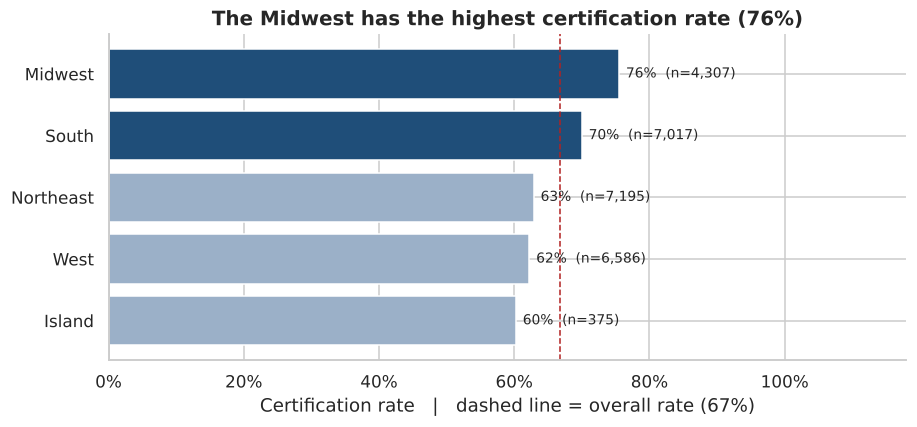

In [15]:
region = cert_rates("region_of_employment")
plot_rates(region, f"The {region.index[0]} has the highest certification rate ({region['rate'].iloc[0]:.0%})")

### 3.6 Company size and age

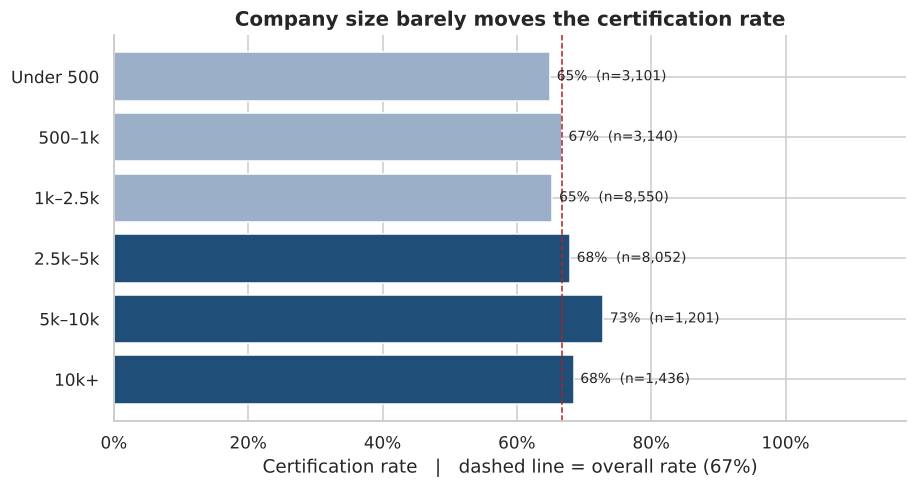

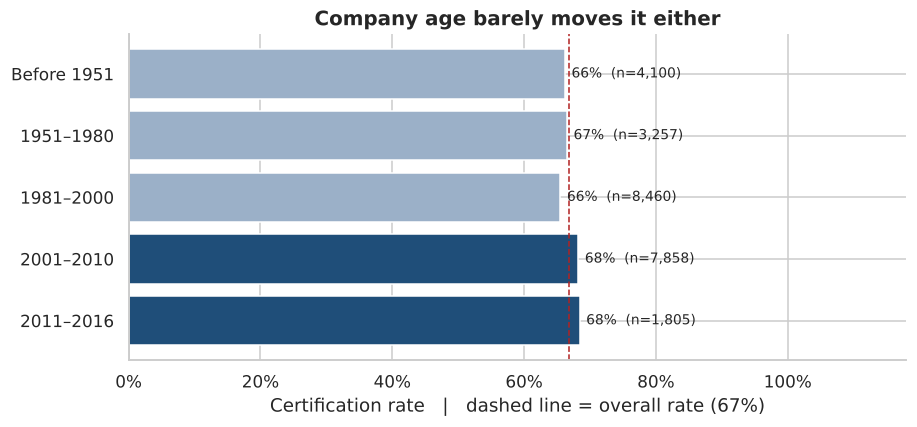

In [16]:
size_bands = pd.cut(df["no_of_employees"], [0, 500, 1000, 2500, 5000, 10000, np.inf],
                    labels=["Under 500", "500–1k", "1k–2.5k", "2.5k–5k", "5k–10k", "10k+"])
size = df.groupby(size_bands)["certified"].agg(rate="mean", cases="size")
plot_rates(size, "Company size barely moves the certification rate")

founded_bands = pd.cut(df["yr_of_estab"], [1799, 1950, 1980, 2000, 2010, 2016],
                       labels=["Before 1951", "1951–1980", "1981–2000", "2001–2010", "2011–2016"])
founded = df.groupby(founded_bands)["certified"].agg(rate="mean", cases="size")
plot_rates(founded, "Company age barely moves it either")

### 3.7 Continent of origin

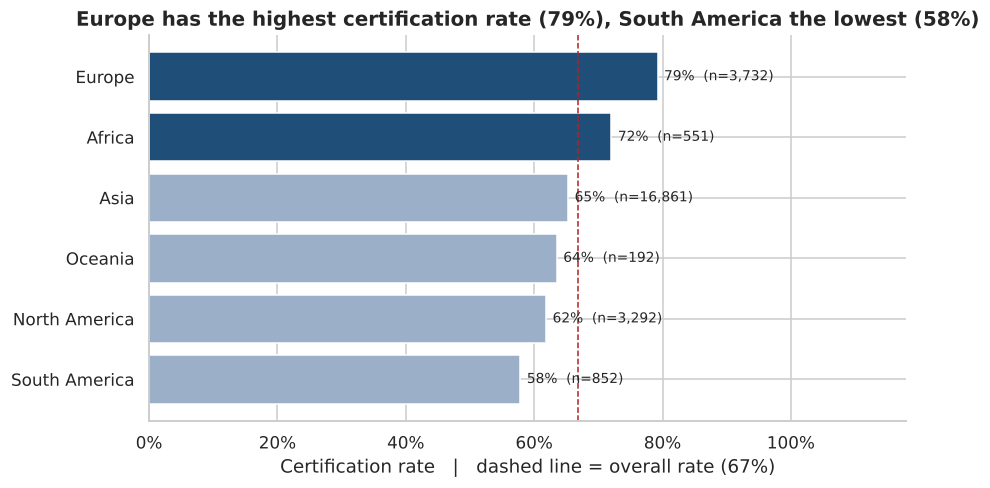

In [17]:
continent = cert_rates("continent")
plot_rates(continent, f"{continent.index[0]} has the highest certification rate ({continent['rate'].iloc[0]:.0%}), "
                      f"{continent.index[-1]} the lowest ({continent['rate'].iloc[-1]:.0%})")

In [18]:
# The three numeric columns are essentially unrelated to each other
df[["no_of_employees", "yr_of_estab", "prevailing_wage"]].corr().round(2)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.00,-0.02,-0.01
yr_of_estab,-0.02,1.00,0.01
prevailing_wage,-0.01,0.01,1.00


**Takeaway.** Three factors stand out: **education** (34% certified for high school up to 87% for doctorates), **job experience** (75% vs 56%) and **wage unit** (hourly jobs only 35%). Continent and region matter more modestly: Europe 79% vs South America 58%, and Midwest 76% vs Island 60%. Company size, company age, wage level and training needs shift the rate by single digits at most.

The strong factors stack. Applicants with a Master's or Doctorate **and** job experience on a yearly wage are certified 91% of the time (6,529 cases). High-school applicants without experience are certified only 32% of the time.

## 4. Preparing the Data for Modeling

* Y/N columns become 1/0, and the other categorical columns are one-hot encoded.
* `yr_of_estab` becomes `company_age`, measured from 2016 (the year of the data).
* The data is split **70% train / 15% validation / 15% test**, stratified so each split keeps the same certified/denied mix. Models are compared and tuned on the validation set, and the test set is used **once**, for the final model only. That way the final score is an honest estimate of performance on new applications.

In [19]:
model_df = df.drop(columns="case_status")
for col in ["has_job_experience", "requires_job_training", "full_time_position"]:
    model_df[col] = (model_df[col] == "Y").astype(int)
model_df["company_age"] = 2016 - model_df["yr_of_estab"]
model_df = model_df.drop(columns="yr_of_estab")
model_df = pd.get_dummies(model_df, drop_first=True, dtype=int,
                          columns=["continent", "education_of_employee", "region_of_employment", "unit_of_wage"])

X = model_df.drop(columns="certified")
y = model_df["certified"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

pd.DataFrame({"rows": [len(X_train), len(X_val), len(X_test)],
              "share certified": [y_train.mean(), y_val.mean(), y_test.mean()]},
             index=["Train", "Validation", "Test"]).round(3)

,rows,share certified
Train,17836,0.668
Validation,3822,0.668
Test,3822,0.668


To check whether balancing the classes helps, I also make two rebalanced copies of the **training set only** (validation and test stay untouched):

* **Oversampled:** SMOTE creates synthetic denied cases until both classes are equal.
* **Undersampled:** certified cases are randomly dropped until both classes are equal.

In [20]:
X_train_over, y_train_over = SMOTE(random_state=SEED).fit_resample(X_train, y_train)
X_train_un, y_train_un = RandomUnderSampler(random_state=SEED).fit_resample(X_train, y_train)

train_sets = {
    "Original": (X_train, y_train),
    "Oversampled": (X_train_over, y_train_over),
    "Undersampled": (X_train_un, y_train_un),
}
pd.DataFrame({name: {"rows": len(yy), "certified": int(yy.sum()), "denied": int((yy == 0).sum())}
              for name, (_, yy) in train_sets.items()}).T

,rows,certified,denied
Original,17836,11913,5923
Oversampled,23826,11913,11913
Undersampled,11846,5923,5923


## 5. Building Baseline Models

### Choosing a metric

A model can be wrong in two ways:

* **False positive:** it certifies an application that should be denied, so a US worker may miss out on the job.
* **False negative:** it denies an application that should be certified, so an employer loses a qualified worker.

Both are costly, so I use **F1 score**, which balances precision (how often a predicted certification is right) and recall (how many real certifications the model catches). As a reference point, certifying everyone gives an F1 of 0.80. A useful model has to beat that clearly.

In [21]:
def scores(model, X, y):
    """Accuracy, recall, precision and F1 for one model on one dataset."""
    pred = model.predict(X)
    return {"Accuracy": accuracy_score(y, pred), "Recall": recall_score(y, pred),
            "Precision": precision_score(y, pred), "F1": f1_score(y, pred)}

def show_confusion(model, X, y, title):
    """Confusion matrix with readable labels."""
    fig, ax = plt.subplots(figsize=(4.8, 4))
    ConfusionMatrixDisplay.from_estimator(model, X, y, display_labels=["Denied", "Certified"],
                                          cmap="Blues", values_format=",", colorbar=False, ax=ax)
    ax.set_title(title); ax.grid(False)
    plt.tight_layout(); plt.show()

print(f"F1 if we certify everyone (validation set): {f1_score(y_val, np.ones(len(y_val))):.3f}")

F1 if we certify everyone (validation set): 0.801


In [22]:
def make_models():
    """Fresh, untuned copies of every candidate model. Scale-sensitive models get a scaler."""
    return {
        "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
        "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier()),
        "Decision Tree": DecisionTreeClassifier(random_state=SEED),
        "Bagging": BaggingClassifier(random_state=SEED),
        "Random Forest": RandomForestClassifier(random_state=SEED),
        "AdaBoost": AdaBoostClassifier(random_state=SEED),
        "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
        "XGBoost": XGBClassifier(random_state=SEED, eval_metric="logloss"),
    }

rows = []
for data_name, (X_tr, y_tr) in train_sets.items():
    for model_name, model in make_models().items():
        model.fit(X_tr, y_tr)
        rows.append({"Training data": data_name, "Model": model_name,
                     "Train F1": f1_score(y_tr, model.predict(X_tr)),
                     "Validation F1": f1_score(y_val, model.predict(X_val))})
baseline = pd.DataFrame(rows)

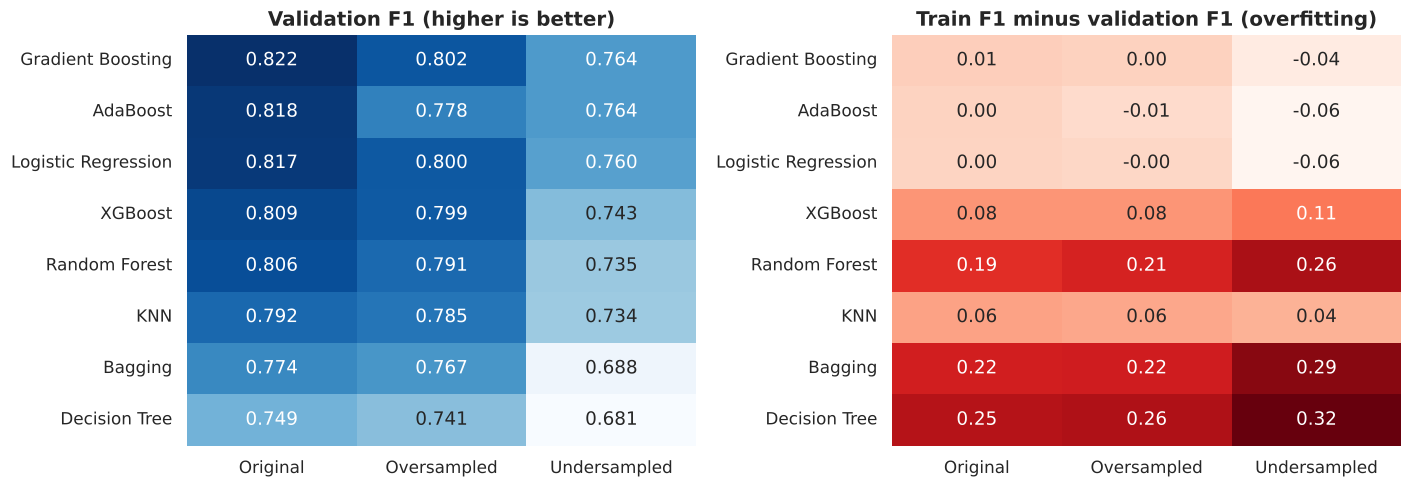

In [23]:
val_f1 = baseline.pivot(index="Model", columns="Training data", values="Validation F1")
val_f1 = val_f1[list(train_sets)].sort_values("Original", ascending=False)
gap = baseline.pivot(index="Model", columns="Training data", values="Train F1")[list(train_sets)] - \
      baseline.pivot(index="Model", columns="Training data", values="Validation F1")[list(train_sets)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sns.heatmap(val_f1, annot=True, fmt=".3f", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("Validation F1 (higher is better)"); axes[0].set_xlabel(""); axes[0].set_ylabel("")
sns.heatmap(gap.loc[val_f1.index], annot=True, fmt=".2f", cmap="Reds", cbar=False, ax=axes[1])
axes[1].set_title("Train F1 minus validation F1 (overfitting)"); axes[1].set_xlabel(""); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

**Takeaway.**

* **The original training data wins for every model.** Rebalancing doesn't help here. Undersampling hurts most, probably because it throws away a third of the training data.
* **The top three are tightly bunched.** Gradient Boosting, AdaBoost and Logistic Regression all score about 0.82 validation F1, with almost no gap between training and validation.
* **The tree-based models overfit.** Decision Tree, Bagging and Random Forest score far higher on training data than on validation data.
* **The bar is low.** 0.82 is only a little above the 0.80 you get by certifying everyone. Section 7 shows a more useful way to read the model than F1 alone.

## 6. Tuning the Strongest Models

I tune the four ensemble models the course focuses on (Random Forest, AdaBoost, Gradient Boosting and XGBoost) on the original training data, since it gave the best validation F1 for every model. Each search tries 20 random combinations from the course's suggested grids and scores them with 5-fold cross-validated F1 on the training data, so the validation set stays clean for comparing the tuned models.

In [24]:
TUNE_SET = train_sets["Original"]   # training data used for tuning (see the baseline results)

def tune(model, param_grid, X_tr, y_tr, n_iter=20):
    """Randomized search on F1; returns the best model refit on the full training data."""
    search = RandomizedSearchCV(model, param_grid, n_iter=n_iter, scoring="f1", cv=5,
                                random_state=SEED, n_jobs=-1)
    search.fit(X_tr, y_tr)
    print(f"Best cross-validated F1: {search.best_score_:.3f}")
    print("Best parameters:", {k: (round(v, 3) if isinstance(v, float) else v)
                               for k, v in search.best_params_.items()})
    return search.best_estimator_

tuned = {}

### Random Forest

In [25]:
%%time
tuned["Random Forest"] = tune(
    RandomForestClassifier(random_state=SEED),
    {"n_estimators": [50, 75, 100, 125],
     "min_samples_leaf": [1, 2, 3, 5, 10],
     "max_features": [0.3, 0.4, 0.5, "sqrt"],
     "max_samples": [0.4, 0.5, 0.6, None]},
    *TUNE_SET)

Best cross-validated F1: 0.826
Best parameters: {'n_estimators': 125, 'min_samples_leaf': 5, 'max_samples': 0.5, 'max_features': 'sqrt'}
CPU times: user 1.53 s, sys: 495 ms, total: 2.03 s
Wall time: 55.6 s


### AdaBoost

In [26]:
%%time
tuned["AdaBoost"] = tune(
    AdaBoostClassifier(random_state=SEED),
    {"n_estimators": [50, 75, 100],
     "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
     "estimator": [DecisionTreeClassifier(max_depth=d, random_state=SEED) for d in (1, 2, 3)]},
    *TUNE_SET)

Best cross-validated F1: 0.823
Best parameters: {'n_estimators': 50, 'learning_rate': 0.05, 'estimator': DecisionTreeClassifier(max_depth=3, random_state=1)}
CPU times: user 1.77 s, sys: 630 ms, total: 2.4 s
Wall time: 1min 5s


### Gradient Boosting

In [27]:
%%time
tuned["Gradient Boosting"] = tune(
    GradientBoostingClassifier(random_state=SEED),
    {"init": [None, AdaBoostClassifier(random_state=SEED)],
     "n_estimators": [50, 75, 100, 150],
     "learning_rate": [0.01, 0.05, 0.1],
     "subsample": [0.7, 0.9, 1.0],
     "max_features": [0.5, 0.7, 1.0]},
    *TUNE_SET)

Best cross-validated F1: 0.825
Best parameters: {'subsample': 1.0, 'n_estimators': 50, 'max_features': 1.0, 'learning_rate': 0.05, 'init': AdaBoostClassifier(random_state=1)}
CPU times: user 2.11 s, sys: 623 ms, total: 2.73 s
Wall time: 1min 14s


### XGBoost

In [28]:
%%time
tuned["XGBoost"] = tune(
    XGBClassifier(random_state=SEED, eval_metric="logloss"),
    {"n_estimators": [50, 75, 100, 150],
     "learning_rate": [0.01, 0.05, 0.1],
     "max_depth": [3, 4, 6],
     "subsample": [0.8, 0.9, 1.0],
     "scale_pos_weight": [0.5, 1, 2],
     "gamma": [0, 1, 3]},
    *TUNE_SET)

Best cross-validated F1: 0.825
Best parameters: {'subsample': 1.0, 'scale_pos_weight': 1, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 3}
CPU times: user 607 ms, sys: 527 ms, total: 1.13 s
Wall time: 9.27 s


## 7. Comparing the Tuned Models and Picking a Final One

In [29]:
comparison = pd.concat(
    {name: pd.DataFrame({"Train": scores(m, *TUNE_SET), "Validation": scores(m, X_val, y_val)})
     for name, m in tuned.items()}, axis=1).round(3)
comparison

Random Forest            AdaBoost            Gradient Boosting  \
                  Train Validation    Train Validation             Train   
Accuracy          0.782      0.742    0.733      0.726             0.742   
Recall            0.897      0.876    0.927      0.932             0.914   
Precision         0.800      0.770    0.739      0.731             0.753   
F1                0.846      0.819    0.823      0.819             0.826   

                     XGBoost             
          Validation   Train Validation  
Accuracy       0.734   0.757      0.744  
Recall         0.917   0.882      0.879  
Precision      0.744   0.782      0.770  
F1             0.821   0.829      0.821

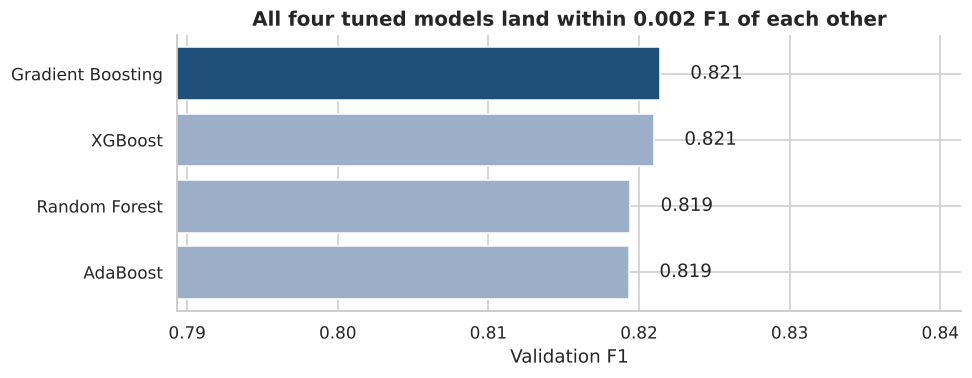

In [30]:
val_scores = pd.DataFrame({name: scores(m, X_val, y_val) for name, m in tuned.items()}).T
best_name = val_scores["F1"].idxmax()
final_model = tuned[best_name]

fig, ax = plt.subplots(figsize=(9, 3.6))
order = val_scores.sort_values("F1").index
ax.barh(order, val_scores.loc[order, "F1"], color=[ACCENT if n == best_name else BASE for n in order])
for y_pos, v in enumerate(val_scores.loc[order, "F1"]):
    ax.text(v + 0.002, y_pos, f"{v:.3f}", va="center")
lo = val_scores["F1"].min()
ax.set_xlim(lo - 0.03, val_scores["F1"].max() + 0.02)
spread = val_scores["F1"].max() - val_scores["F1"].min()
ax.set_title(f"All four tuned models land within {spread:.3f} F1 of each other")
ax.set_xlabel("Validation F1"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Tuning didn't help.** All four tuned models land within 0.002 F1 of each other on validation (0.819–0.821), slightly *below* untuned Gradient Boosting (0.822). That suggests the model is limited by the information in the data, not by its settings.

I pick **Gradient Boosting**. It ties XGBoost for the best validation F1, and its training and validation scores are almost identical (0.826 vs 0.821), so it should hold up on new applications. XGBoost would be an equally reasonable choice.

### Final check on the untouched test set

,Gradient Boosting (test)
Accuracy,0.733
Recall,0.907
Precision,0.747
F1,0.819


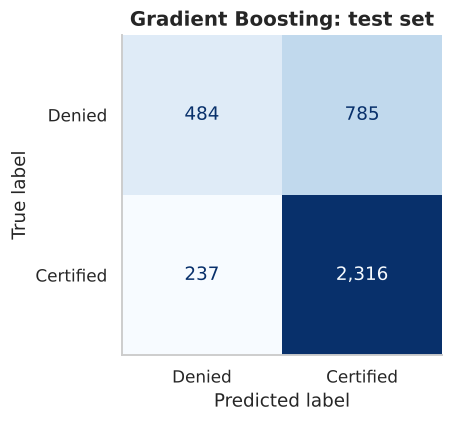

In [31]:
test_scores = pd.Series(scores(final_model, X_test, y_test), name=f"{best_name} (test)").round(3)
display(test_scores.to_frame())
show_confusion(final_model, X_test, y_test, f"{best_name}: test set")

On the test set the model scores **0.819 F1**, in line with validation, so it generalizes as expected. The confusion matrix shows its main weakness:

* it correctly identifies **91%** of applications that were certified (2,316 of 2,553), but
* it flags only **38%** of the applications that were denied (484 of 1,269).

In other words, it is good at recognizing strong applications and weak at spotting the ones that will be denied.

### Using the model for triage

Instead of a yes/no prediction, the model's probability score can rank applications. Here the test set is split into four equal groups by score, and each bar shows how often that group was actually certified.

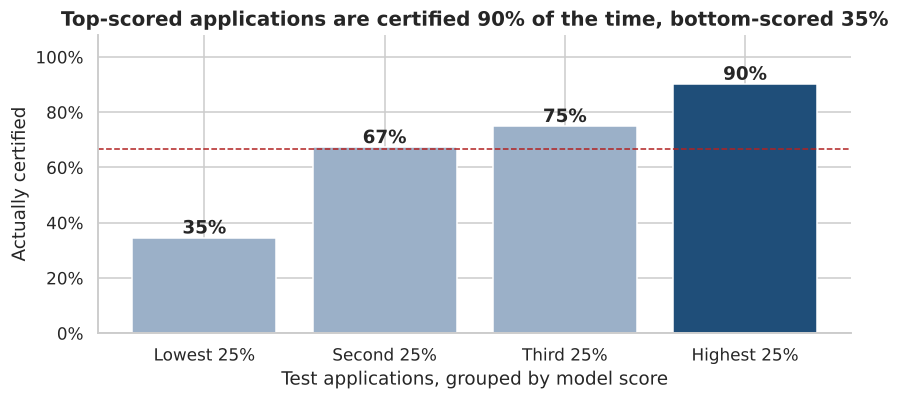

In [32]:
proba = pd.Series(final_model.predict_proba(X_test)[:, 1], index=X_test.index)
quarter = pd.qcut(proba.rank(method="first"), 4,
                  labels=["Lowest 25%", "Second 25%", "Third 25%", "Highest 25%"])
triage = y_test.groupby(quarter).agg(rate="mean", cases="size")

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(triage.index.astype(str), triage["rate"],
       color=[BASE, BASE, BASE, ACCENT])
for x, r in enumerate(triage["rate"]):
    ax.text(x, r + 0.015, f"{r:.0%}", ha="center", fontweight="bold")
ax.axhline(overall_rate, color="firebrick", linestyle="--", linewidth=1)
ax.set_ylim(0, 1.08); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title(f"Top-scored applications are certified {triage['rate'].iloc[-1]:.0%} of the time, "
             f"bottom-scored {triage['rate'].iloc[0]:.0%}")
ax.set_xlabel("Test applications, grouped by model score"); ax.set_ylabel("Actually certified")
plt.tight_layout(); plt.show()

This is the most practical way to use the model. Applications in the **top quarter** of scores were certified **90%** of the time, well above the 67% average. Applications in the **bottom quarter** were certified only **35%** of the time. The middle half sits at or a little above the average (67% and 75%), so the model adds less there.

### What drives the model's decisions?

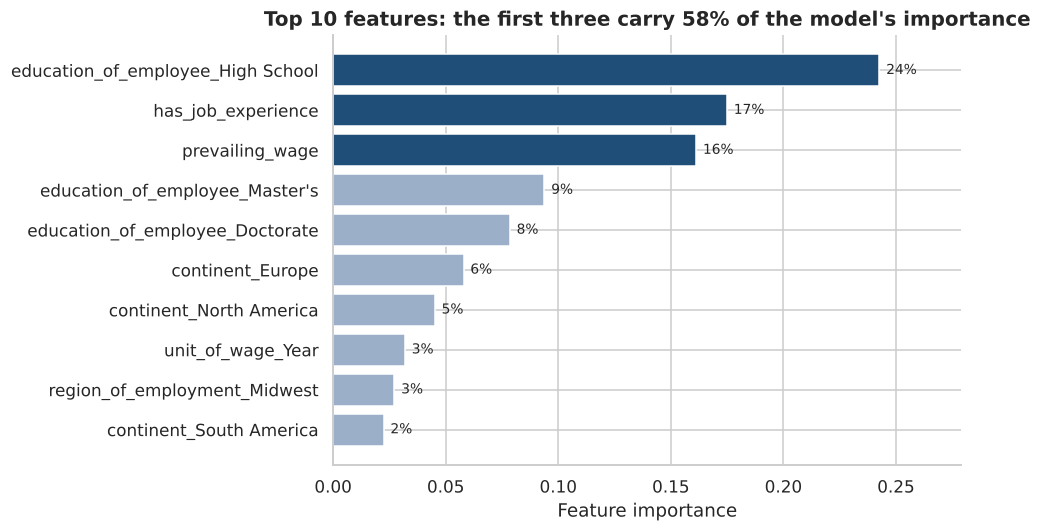

In [33]:
importance = pd.Series(final_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
top = importance.head(10)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.index, top.values, color=[ACCENT] * 3 + [BASE] * (len(top) - 3))
ax.invert_yaxis()
for y_pos, v in enumerate(top.values):
    ax.text(v + 0.003, y_pos, f"{v:.0%}", va="center", fontsize=9)
ax.set_xlim(0, top.max() * 1.15)
ax.set_title(f"Top 10 features: the first three carry {top.head(3).sum():.0%} of the model's importance")
ax.set_xlabel("Feature importance"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Takeaway.** Education, job experience and wage carry most of the model's weight, which matches the exploratory analysis. One caution about `prevailing_wage`: Section 3.4 showed that wage *level* doesn't predict the outcome within a wage unit. The model is most likely using wage to recognize hourly jobs, whose wages are all numbers under 1,000. Feature importance shows what the model relies on, not what causes certification.

## 8. Conclusions and Recommendations

**1. Use the model to fast-track, not to deny.** Applications in the model's top quarter are certified 90% of the time and could go through a lighter review. The model misses most denials, so it should never be the reason an application is rejected. Everything outside the top quarter should keep a full human review.

**2. Profile of applications likely to be certified:**
* Master's or Doctorate degree
* prior job experience
* a salaried (yearly-wage) position
* origin in Europe or Africa; employment in the Midwest or South

**3. Profile of applications that need a closer look:**
* high school education, especially without job experience (32% certified)
* hourly-wage positions (35% certified)
* origin in South America or North America; employment in the Island, West or Northeast regions

**4. Don't read much into company size, company age or wage level.** Company size and age shift the certification rate by single digits at most, and wage level within a wage unit doesn't shift it at all.

**5. Collect the data that's missing.** The model tops out around 0.82 F1, and tuning didn't change that. The biggest gains would come from new information rather than new algorithms, such as job title or occupation, the offered salary compared with the prevailing wage, and the filing date.

### Limitations and Next Steps

* The data covers a single period with no dates, so trends over time can't be assessed.
* The relationships here are associations, not causes. For example, education may stand in for occupation, which isn't in the data.
* Hourly wages in the file (median about \$373 per hour) look unrealistic, which suggests a data-quality issue worth raising with OFLC.
* **Natural extension:** tune the decision threshold for a "fast-track" use case (aiming for high precision) and test whether occupation data improves recall on denials.